# Solving Max Independent Set Problem Using iQ-Xtreme

**Inspiration-Q**

---

The Maximum Independent Set (MIS) problem in graph theory is the task of finding the
largest independent set in a graph, where an independent set is a set of vertices such
that no two vertices are adjacent.

For example, the red dots in the figure below are all examples of Independent Sets (taken from
Wikipedia). Only the middle ones, with 4 nodes each, are Maximal Independent Sets.

![max_independent_set_wikipedia_example](./tutorials/QUBO/figures/cube-maximal-independence.png)

## Content

1. Solving unweighted Max Independent Set Problem Using iQ-Xtreme

    * Creating a Random Graph

    * QUBO Formulation of the Problem

    * Solving the QUBO with iQ-Xtreme

    * Visualizing Solution

    * Comparison with NetworkX's solution

2. Solving Weighted Max Independent Set Problem Using iQ-Xtreme

    * Creating a Weighted Random Graph

    * QUBO Formulation of the Problem

    * Solving the QUBO iQ-Xtreme

    * Visualizing Solution

### iQ-Xtreme QUBO API

In [ ]:

from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from networkx.algorithms.approximation import maximum_independent_set

import iq.api.iqrestapi
import iq.optim.qubo

In [ ]:
iq.api.iqrestapi.initialize_credentials("YOUR_API_KEY")

## 1. Solving unweighted Max Independent Set Problem Using iQ-Xtreme

### Creating a random Graph

Create an example graph

In [ ]:
G = nx.Graph()
G.add_nodes_from([1, 2, 3, 4, 5, 6, 7, 8])
G.add_edges_from(
    [
        (1, 2),
        (1, 4),
        (1, 5),
        (2, 6),
        (2, 3),
        (3, 4),
        (3, 7),
        (4, 8),
        (5, 6),
        (5, 8),
        (6, 7),
        (7, 8),
    ]
)
nx.draw_circular(G, with_labels=True)
plt.show()
adj_matrix = np.array(nx.to_numpy_array(G))

### QUBO formulation

In order to better understand the formulation, let's introduce an easier graph:

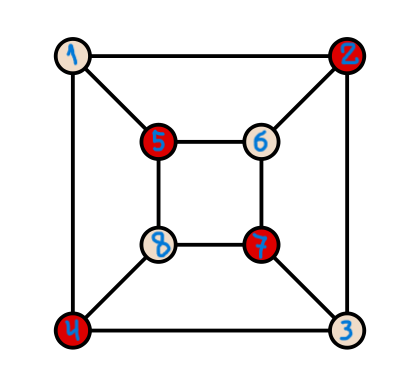

On the picture we can already see the valid solution, but how would we solve in a
systematic fashion?

We want to maximize the number of nodes in an independent set and not allow these nodes
to be connected (otherwise the set would not fulfil the requirement of independence). We
can achieve this by introducing penalisation for combinations not respecting such
constraint. The following cost function captures that logic.

$$
\min (-\sum\limits_{i\in N}x_i + \lambda\sum\limits_{(ij)\in E}x_i x_j )
$$


$x_i = 1$ if the node is considered in the independent set and $x_i = 0$ if the node is not
considered in the independent set.

Here the first term tries to maximize the number of nodes in the set, while the second one tries
to minimize the number of edges that connect nodes in the set. The variables are:

* $λ$: penalization coefficient

* N: set of nodes

* E: set of edges in the graph (each edge contains two numbers - the nodes which it is connecting)


For our particular case, the cost function will be like,

$$
(-x_1-x_2-x_3-x_4-x_5-x_6-x_7-x_8)
+ \lambda\cdot (x_1\, x_2 + x_1\, x_4 + x_1\, x_5 + x_2\, x_6 + ...)
$$


If we write it as a symmetric matrix, it will look like:

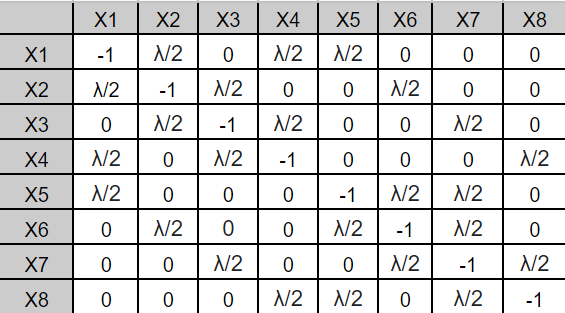


We could build the QUBO matrix based on the adjacency matrix as follows

In [ ]:
problem_size = G.number_of_nodes()
λ = problem_size
adj_matrix = np.array(nx.to_numpy_array(G))
q_matrix = adj_matrix * (λ / 2)
# quadratic terms
for i in range(problem_size):
    q_matrix[i, i] = -1

In [ ]:
def compute_maxindset_qubo_matrix(G, lmbda: float = 1.5):
    """Build the QUBO matrix for the unweighted Max Independent Set problem.

    Parameters
    ----------
    G : nx.Graph
        Input graph.
    lmbda : float, optional
        Penalty coefficient. Defaults to the number of nodes in G.

    Returns
    -------
    np.ndarray
        Symmetric QUBO matrix of shape (n, n).
    """
    adj_matrix = np.array(nx.to_numpy_array(G))
    problem_size = G.number_of_nodes()
    Q = -np.eye(problem_size) + lmbda * adj_matrix
    Q = (Q + Q.T) / 2
    return Q

In [ ]:
Q = compute_maxindset_qubo_matrix(G)

### Solving QUBO problem with iQ-Xtreme

In [ ]:
x, cost = iq.optim.qubo.solve_QUBO(Q, shots=10, steps=3000)
print("MIS size:", -cost)
x_array = np.array(x)
print("Check cost function:", -x_array.T @ Q @ x_array)

### Visualizing the solution

Nodes belonging to the MIS shown in blue

In [ ]:
def draw_solution(G, solution_array):
    """Draw the graph with MIS nodes highlighted in blue.

    Parameters
    ----------
    G : nx.Graph
        Input graph.
    solution_array : list
        Binary array where 1 indicates the node is in the independent set.
    """
    pos = nx.circular_layout(G)
    color_map = []
    for node in solution_array:
        if node == 0:
            color_map.append("orange")
        else:
            color_map.append("blue")

    nx.draw(G, pos, node_color=color_map, with_labels=True)

    plt.show()
    return

In [ ]:
draw_solution(G, x)

## Comparison with NetworkX's solution

In [ ]:
def compare_random_sizes(minimum_size=5, maximum_size=100, num_reads=10, lmbda=None):
    """Compare iQ-Xtreme and NetworkX MIS solutions across random graphs of varying sizes.

    Parameters
    ----------
    minimum_size : int, optional
        Minimum graph size to test. Default is 5.
    maximum_size : int, optional
        Maximum graph size to test (exclusive). Default is 100.
    num_reads : int, optional
        Number of shots for the iQ-Xtreme solver. Default is 10.
    lmbda : float, optional
        Penalty coefficient. Defaults to the number of nodes in each graph.
    """
    list_s_iq = []
    list_indset_networkx = []

    seed = 0
    step_size = 5
    for size in range(minimum_size, maximum_size, step_size):
        rng = np.random.default_rng(seed)
        G = nx.gnp_random_graph(n=size, p=0.5, seed=rng, directed=False)

        networkx_sol = maximum_independent_set(G)
        list_indset_networkx.append(len(networkx_sol) / size)

        Q = compute_maxindset_qubo_matrix(G, lmbda=1.5)
        iq_sol, _ = iq.optim.qubo.solve_QUBO(Q, shots=min(100, size * 2))
        cost = np.count_nonzero(np.array(iq_sol) == 1)
        list_s_iq.append(cost / size)

    plt.figure(figsize=(10, 8))
    plt.scatter(range(minimum_size, maximum_size, step_size), list_s_iq, marker="o")
    plt.scatter(range(minimum_size, maximum_size, step_size), list_indset_networkx, marker="x")
    plt.legend(["iQ", "NetworkX"])
    plt.title("Comparison")
    plt.ylabel("Max Independent Set size / Graph size (higher is better)")
    plt.xlabel("Graph size")
    return

In [ ]:
compare_random_sizes(minimum_size=10, maximum_size=50)

We readily observe that iQ-Xtreme outperforms Networks!

### Summary function

function that returns a list of whether node is included in Subset (1) or not (0)
based on iQ-Xtreme

In [ ]:
def solve_maxindset(G):
    """Solve the Max Independent Set problem and draw the solution.

    Parameters
    ----------
    G : nx.Graph
        Input graph.

    Returns
    -------
    list
        Binary solution array (1 = node in independent set, 0 = node not included).
    """
    Q = compute_maxindset_qubo_matrix(G)
    x, cost = iq.optim.qubo.solve_QUBO(Q)
    draw_solution(G, x)
    return x

**Basic Example**

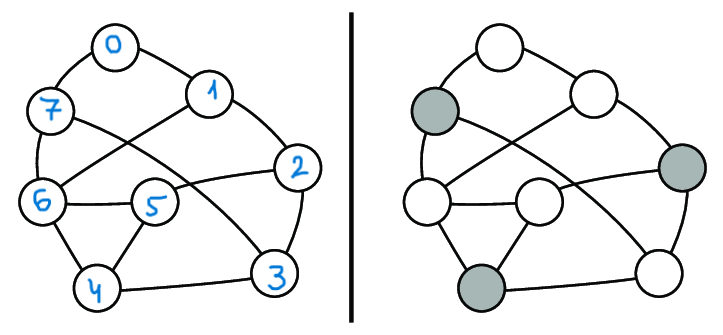

In [ ]:
G = nx.Graph()
G.add_nodes_from([0, 1, 2, 3, 4, 5, 6, 7])
G.add_edges_from(
    [
        (0, 1),
        (0, 7),
        (1, 6),
        (1, 2),
        (7, 3),
        (7, 6),
        (2, 5),
        (2, 3),
        (3, 4),
        (4, 5),
        (5, 6),
        (4, 6),
    ]
)
solve_maxindset(G)

## 2. Solving a weighted Max Independent Set Problem Using iQ-Xtreme

In this case we generalize the MIS problem by introducing weights associated to each
node of the graph. The goal then is to find an independent set that maximizes the total
weight.

### Random Weighted Graph (Weighted Nodes)


In [ ]:
n = 8
G = nx.gnp_random_graph(n, 0.5, seed=None, directed=False)  # random graph of size i
rng = np.random.default_rng(123321)
weights = list()
for i in range(n):
    weights.append(round(rng.uniform(0, 1), 2))  # random weights for all the vertices

### Qubo Formulation of the Problem

The cost function in this case will be:

$$ \min ( -\sum\limits_{i\in N}w_i\cdot X_i + λ\sum\limits_{(ij)\in E}x_i\cdot x_j )$$

Because we want to have an independent set with the biggest weight.

We can create a QUBO matrix for this problem directly with the adjacency matrix

In [ ]:
problem_size = G.number_of_nodes()
adj_matrix = np.array(nx.to_numpy_array(G))
q_matrix = adj_matrix
# quadratic terms
for i in range(problem_size):
    q_matrix[i, i] = -1 * weights[i]

In [ ]:
def compute_weighted_maxindset_qubo_matrix(G, weights):
    """Build the QUBO matrix for the weighted Max Independent Set problem.

    Parameters
    ----------
    G : nx.Graph
        Input graph.
    weights : list
        Node weights. weights[i] is the weight of node i.

    Returns
    -------
    np.ndarray
        Symmetric QUBO matrix of shape (n, n).
    """
    adj_matrix = np.array(nx.to_numpy_array(G))
    problem_size = G.number_of_nodes()
    lmbda = max(weights) + 1
    Q = lmbda * adj_matrix
    for i in range(problem_size):
        Q[i, i] = -weights[i]
    Q = (Q + Q.T) / 2
    return Q

In [ ]:
Q = compute_weighted_maxindset_qubo_matrix(G, weights)

### Solving QUBO problem with iQ-Xtreme

In [ ]:
x, cost = iq.optim.qubo.solve_QUBO(Q)
print("weighted MIS size:", -cost)
x_array = np.array(x)
print("Check cost function:", -x_array.T @ Q @ x_array)

### Visualizing solution

In [ ]:
def draw_weighted_solution(G, solution_array, weights):
    """Draw the weighted graph with independent set nodes highlighted in blue.

    Parameters
    ----------
    G : nx.Graph
        Input graph.
    solution_array : list
        Binary array where 1 indicates the node is in the independent set.
    weights : list
        Node weights used as labels in the drawing.
    """
    weights_dict = defaultdict(int)
    for i in G.nodes:
        weights_dict[i] = weights[i]

    pos = nx.circular_layout(G)
    color_map = []
    for node in solution_array:
        if node == 0:
            color_map.append("orange")
        else:
            color_map.append("blue")

    nx.draw(G, pos, node_color=color_map, labels=weights_dict, with_labels=True)

    plt.show()
    return

In [ ]:
draw_weighted_solution(G, x, weights)

### Summary function

function that returns a list of whether node is included in Subset (1) or not (0) and
also draws the solution.

In [ ]:
def solve_weighted_maxindset(G, weights):
    """Solve the weighted Max Independent Set problem and draw the solution.

    Parameters
    ----------
    G : nx.Graph
        Input graph.
    weights : list
        Node weights.

    Returns
    -------
    list
        Binary solution array (1 = node in independent set, 0 = node not included).
    """
    Q = compute_weighted_maxindset_qubo_matrix(G, weights)
    x, cost = iq.optim.qubo.solve_QUBO(Q)
    draw_weighted_solution(G, x, weights)
    return x

In [ ]:
G = nx.Graph()
G.add_nodes_from([0, 1, 2, 3, 4, 5, 6])
G.add_edge(0, 2)
G.add_edge(1, 3)
G.add_edge(3, 4)
G.add_edge(3, 5)
G.add_edge(3, 6)
G.add_edge(1, 4)
weights = [0.1, 0.7, 0.15, 0.99, 0.8, 0.4, 0.3]
solve_weighted_maxindset(G, weights)